# Model and Evaluation (No Points or Credit Score Features) for Approval Predict

## Objective:
Answer business requirement 2: The client aims to offer a guide for potential applicants by identifying the influential factors that contribute to loan approval. These insights will be used to recommend specific improvements for applicants and guide them to increase their chances of having a loan approved.

Test model performance without points and credit score feature and then compare with final model.

## Inputs
outputs/datasets/collection/loan_approved.csv

## Outputs
Feature importance plot

## Imports and required libraries

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from feature_engine.transformation import BoxCoxTransformer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    make_scorer,
    recall_score
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
sns.set(style="whitegrid")

## Update Working Directory

In [2]:
current_dir = os.getcwd()
current_dir

'/Users/davidcarr/Desktop/vscode-projects/Approval_Predict/jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'/Users/davidcarr/Desktop/vscode-projects/Approval_Predict'

## Load data

The dataset is loaded with name and city removed. The dataframe for the target loan_approved is converted to an iteger. The loan_to_income feature is added. The variable reduced_features has been created for analysis.

In [5]:
root = os.getcwd()
file_path = Path(root) / "outputs" / "datasets" / "collection" / "loan_approval.csv"
df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)

df['loan_approved'] = df['loan_approved'].astype(int)
df['loan_to_income'] = df['loan_amount'] / df['income']

reduced_features = ['years_employed', 'loan_amount', 'loan_to_income', 'income']
X = df[reduced_features].copy()
y = df['loan_approved'].copy()

X.head(3), y.head(3)

(   years_employed  loan_amount  loan_to_income  income
 0              27        39698        0.348809  113810
 1              28        15446        0.346385   44592
 2              13        11189        0.336228   33278,
 0    0
 1    0
 2    0
 Name: loan_approved, dtype: int64)

Split into Train/Test sets

The dataset is split into a train (80%) and test set (20%). The dataset was trialed with 70/30 but did not add any added value to the findings.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Shapes:")
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Train/Test Shapes:


((1600, 4), (1600,), (400, 4), (400,))

## Handle Class Imbalance

A target imblanace was found in previous notebooks. Therefore, we handled class imbalance using Synthetic Minority Oversampling Technique (SMOTE).

After SMOTE: (1808, 4) (1808,)


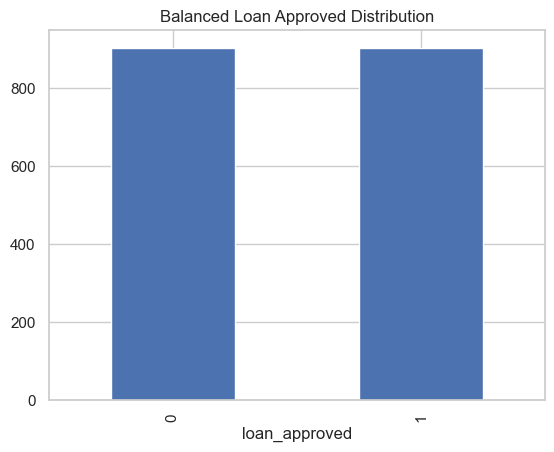

In [7]:
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(kind='bar', title='Balanced Loan Approved Distribution')
plt.show()

Build ML pipeline

In [8]:
def loan_approval_pipeline(model):
    """
    Create a machine learning pipeline that applies Box-Cox
    transformations, robust scaling, and a classification model for predicting
    loan approval.
    
    """
    
    pipeline = Pipeline([
        ('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    return pipeline

In [9]:
def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation that includes
    feature transformations, robust scaling and a classifier model.
    """
    return Pipeline([
        ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
        ("scaler", RobustScaler()),
        ("model", model),
    ])

## Grid search

This step identifies the best-performing model before detailed hyperparameter tuning.

In [10]:
models_quick_search = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42)
}

params_quick_search = {
    "LogisticRegression": {},
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
    "XGBClassifier": {},
}

## Hyperparameter Optimisation

A custom class, HyperparameterOptimizationSearch, was created by the CodeInstitute to perform grid searches across selected parameter spaces for each model.

In [11]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

In [12]:
search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train_bal,
    y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    cv=5,
    n_jobs=-1,
    verbose=1
)


Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [13]:
results_summary, search_pipelines = search.score_summary(sort_by='mean_score')
display(results_summary)

,estimator,min_score,mean_score,max_score,std_score
4,ExtraTreesClassifier,0.530387,0.667029,0.900552,0.124412
5,AdaBoostClassifier,0.574586,0.661486,0.707182,0.048348
6,XGBClassifier,0.585635,0.660405,0.801105,0.074957
0,LogisticRegression,0.607735,0.658171,0.707182,0.036015
2,RandomForestClassifier,0.552486,0.657084,0.856354,0.105391
1,DecisionTreeClassifier,0.533333,0.646998,0.823204,0.098269
3,GradientBoostingClassifier,0.569061,0.643738,0.696133,0.055589


In [14]:
best_model = results_summary.iloc[0, 0]
pipeline_clf = search.grid_searches[best_model].best_estimator_
pipeline_clf

,steps,"[('boxcox', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,variables,['loan_to_income']
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,n_estimators,100


In [15]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=prediction, y_pred=y),
        columns=[["Actual " + sub for sub in label_map]],
        index=[["Prediction " + sub for sub in label_map]]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

In [16]:
print(f"Quick-search best model: {best_model}")

clf_performance(
    X_train_bal, y_train_bal,
    X_test, y_test,
    pipeline_clf,
    label_map=["Rejected", "Approved"]
)

Quick-search best model: ExtraTreesClassifier
#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904               0
Prediction Approved               0             904


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       1.00      1.00      1.00       904

    accuracy                           1.00      1808
   macro avg       1.00      1.00      1.00      1808
weighted avg       1.00      1.00      1.00      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             138              87
Prediction Approved              79              96


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.61      0.64      0.62       217
    Approved       0.55      0.52      0

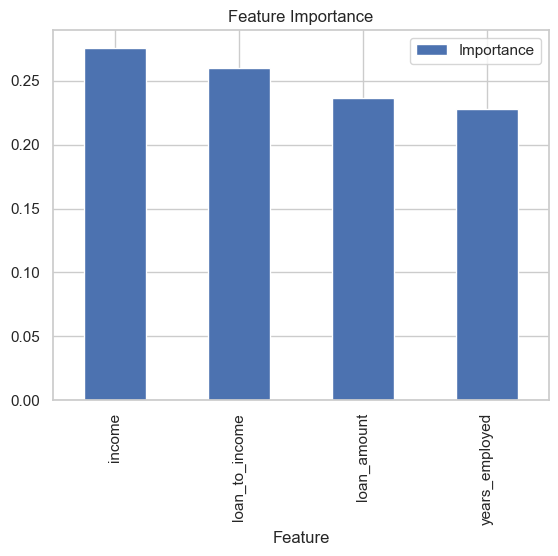

<Figure size 640x480 with 0 Axes>

In [17]:
top_features = X_train.columns

# Create a dataframe to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': top_features,
    'Importance': pipeline_clf['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Plots the feature importance
df_feature_importance.plot(kind="bar", x="Feature", y="Importance")
plt.title("Feature Importance")
plt.show()
plt.tight_layout()
plt.show()